<a href="https://colab.research.google.com/github/mabdulatalhakh213-ux/Northstar/blob/main/Northstar_R.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# NorthStar Urban Mobility and Logistics
## Section 1 — R Analysis
### SQL Operations, SQL in R, Data Transformation, and Visualisation

In [14]:
install.packages(c("DBI", "RSQLite", "sqldf", "dplyr", "ggplot2", "readr", "lubridate", "stringr"))

library(DBI)
library(RSQLite)
library(sqldf)
library(dplyr)
library(ggplot2)
library(readr)
library(lubridate)
library(stringr)

cat("Packages loaded successfully\n")

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependencies ‘gsubfn’, ‘proto’, ‘chron’


Loading required package: gsubfn

Loading required package: proto

Warning message:
“no DISPLAY variable so Tk is not available”


Packages loaded successfully


In [15]:
options(stringsAsFactors = FALSE)
cat("R environment ready\n")

R environment ready


In [16]:
base_url <- "https://raw.githubusercontent.com/mabdulatalhakh213-ux/Northstar/main/"

customers  <- read_csv(paste0(base_url, "customers.csv"), show_col_types = FALSE)
app_events <- read_csv(paste0(base_url, "app_events.csv"), show_col_types = FALSE)
complaints <- read_csv(paste0(base_url, "complaints.csv"), show_col_types = FALSE)
deliveries <- read_csv(paste0(base_url, "deliveries.csv"), show_col_types = FALSE)
drivers    <- read_csv(paste0(base_url, "drivers.csv"), show_col_types = FALSE)
hubs       <- read_csv(paste0(base_url, "hubs.csv"), show_col_types = FALSE)
incidents  <- read_csv(paste0(base_url, "incidents.csv"), show_col_types = FALSE)
orders     <- read_csv(paste0(base_url, "orders.csv"), show_col_types = FALSE)
vehicles   <- read_csv(paste0(base_url, "vehicles.csv"), show_col_types = FALSE)

In [17]:
head(orders)
head(deliveries)
head(customers)

order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,special_handling_flag
<chr>,<chr>,<chr>,<dttm>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,<dbl>
O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,0
O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,AIRPORT,Low,109.30,App,0
O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,AIRPORT,High,33.50,Phone,0
O00004,C0520,Parcel,2025-01-11 17:15:00,2,RiverSide,North,Medium,10.04,App,1
O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,SOUTH,Low,125.58,Phone,0
O00006,C0437,Retail,2024-08-05 04:55:00,1,CENTRAL,East,High,151.44,Web,1


delivery_id,order_id,driver_id,vehicle_id,hub_id,dispatch_time,delivery_completed_at,delivery_status,route_distance_km,manual_route_override_count,proof_of_completion_missing,customer_rating_post_delivery,fuel_or_charge_cost
<chr>,<chr>,<chr>,<chr>,<chr>,<dttm>,<dttm>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
DL00001,O00938,D004,V056,H05,2024-06-18 10:57:00,2024-06-19 09:05:59,Failed,17.26,1,0,3.07,12.05
DL00002,O00004,D138,V007,H02,2025-01-11 18:45:00,2025-01-11 17:39:00,OnTime,10.34,1,0,5.00,13.41
DL00003,O00639,D006,V049,H02,2025-06-02 20:39:00,2025-06-02 21:45:32,OnTime,7.92,0,0,4.98,8.51
DL00004,O00313,D116,V055,H02,2024-03-08 23:31:00,2024-03-09 23:30:08,Delayed,16.42,0,0,4.18,13.62
DL00005,O00844,D108,V034,H01,2025-09-21 11:43:00,2025-09-21 15:45:34,OnTime,14.52,1,0,4.18,9.22
DL00006,O00029,D037,V098,H03,2024-09-11 12:40:00,2024-09-12 17:11:52,Delayed,13.84,0,0,1.57,9.58


customer_id,age,home_zone,customer_type,signup_date,loyalty_score,app_engagement_score,preferred_channel,account_status
<chr>,<dbl>,<chr>,<chr>,<dttm>,<dbl>,<dbl>,<chr>,<chr>
C0001,26,North,SME,2024-11-27 04:25:00,44.9,69.2,App,Active
C0002,61,AIRPORT,Consumer,2025-10-28 01:04:00,55.4,66.6,App,Active
C0003,66,East,Consumer,2025-07-02 03:23:00,75.9,33.8,NA,Active
C0004,75,CENTRAL,Consumer,2025-08-19 01:58:00,32.5,33.0,App,Active
C0005,26,Riverside,Consumer,2025-06-03 06:02:00,55.9,100.0,Web,Active
C0006,41,WEST,Consumer,2024-03-29 13:26:00,39.9,43.3,Web,Active


In [18]:
clean_names <- function(df) {
  names(df) <- tolower(trimws(names(df)))
  names(df) <- gsub("\\s+", "_", names(df))
  df
}

customers  <- clean_names(customers)
app_events <- clean_names(app_events)
complaints <- clean_names(complaints)
deliveries <- clean_names(deliveries)
drivers    <- clean_names(drivers)
hubs       <- clean_names(hubs)
incidents  <- clean_names(incidents)
orders     <- clean_names(orders)
vehicles   <- clean_names(vehicles)

cat("Column names standardized\n")

Column names standardized


In [19]:
con <- dbConnect(SQLite(), ":memory:")
cat("SQLite connection created\n")

SQLite connection created


In [20]:
dbWriteTable(con, "customers", customers, overwrite = TRUE)
dbWriteTable(con, "app_events", app_events, overwrite = TRUE)
dbWriteTable(con, "complaints", complaints, overwrite = TRUE)
dbWriteTable(con, "deliveries", deliveries, overwrite = TRUE)
dbWriteTable(con, "drivers", drivers, overwrite = TRUE)
dbWriteTable(con, "hubs", hubs, overwrite = TRUE)
dbWriteTable(con, "incidents", incidents, overwrite = TRUE)
dbWriteTable(con, "orders", orders, overwrite = TRUE)
dbWriteTable(con, "vehicles", vehicles, overwrite = TRUE)

dbListTables(con)

[1] "app_events" "complaints" "customers"  "deliveries" "drivers"   
[6] "hubs"       "incidents"  "orders"     "vehicles"

In [21]:
select_result <- sqldf("
  SELECT order_id, customer_id, service_type, order_value, booking_channel
  FROM orders
  ORDER BY order_value DESC
  LIMIT 10
")
select_result

order_id,customer_id,service_type,order_value,booking_channel
<chr>,<chr>,<chr>,<dbl>,<chr>
O00980,C0545,Parcel,510.06,App
O00529,C0422,Retail,355.62,App
O00892,C0157,Passenger,326.38,Web
O01207,C0197,Business,321.68,App
O00694,C0380,Passenger,307.50,Web
O00013,C0234,Retail,302.70,App
O01145,C0548,Passenger,301.38,App
O00052,C0150,Retail,293.65,API
O00860,C0076,Medical,292.33,App


In [22]:
new_order <- data.frame(
  order_id = "TEST99999",
  customer_id = "C0001",
  service_type = "Parcel",
  order_created_at = Sys.time(),
  promised_window_hours = 2,
  pickup_zone = "North",
  dropoff_zone = "South",
  priority_level = "Medium",
  order_value = 50,
  booking_channel = "App",
  special_handling_flag = 0
)

orders_inserted <- bind_rows(orders, new_order)

cat("Original rows:", nrow(orders), "\n")
cat("After insert  :", nrow(orders_inserted), "\n")

Original rows: 1250 
After insert  : 1251 


In [23]:
orders_updated <- orders_inserted
orders_updated$service_type[1] <- "UpdatedType"
head(orders_updated[, c("order_id", "service_type")], 3)

order_id,service_type
<chr>,<chr>
O00001,UpdatedType
O00002,Passenger
O00003,Passenger


In [24]:
orders_deleted <- orders_updated %>% filter(order_id != "TEST99999")

cat("Rows after delete:", nrow(orders_deleted), "\n")

Rows after delete: 1250 


In [25]:
agg_service <- sqldf("
  SELECT service_type,
         COUNT(*) AS total_orders,
         ROUND(AVG(order_value), 2) AS avg_order_value,
         ROUND(SUM(order_value), 2) AS total_revenue,
         MIN(order_value) AS min_order_value,
         MAX(order_value) AS max_order_value
  FROM orders
  GROUP BY service_type
  ORDER BY total_orders DESC
")
agg_service

service_type,total_orders,avg_order_value,total_revenue,min_order_value,max_order_value
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Passenger,341,96.07,32761.11,5.92,326.38
Parcel,308,87.62,26985.62,3.57,510.06
Retail,297,90.01,26734.06,4.22,355.62
Business,165,92.25,15220.43,6.28,321.68
Medical,139,87.14,12111.93,2.04,292.33


In [26]:
agg_cost <- sqldf("
  SELECT
    delivery_status,
    COUNT(*) AS total_deliveries,
    ROUND(SUM(fuel_or_charge_cost), 2) AS total_cost,
    ROUND(AVG(fuel_or_charge_cost / route_distance_km), 2) AS avg_cost_per_km
  FROM deliveries
  GROUP BY delivery_status
  ORDER BY total_deliveries DESC
")
agg_cost

delivery_status,total_deliveries,total_cost,avg_cost_per_km
<chr>,<int>,<dbl>,<dbl>
OnTime,616,7809.68,1.22
Delayed,202,2654.02,1.31
Failed,132,1735.53,1.35


In [27]:
q1 <- sqldf("
  SELECT
    o.service_type,
    COUNT(*) AS total_orders,
    SUM(CASE WHEN LOWER(d.delivery_status) IN ('delayed','failed','exception','cancelled','returned') THEN 1 ELSE 0 END) AS problem_orders,
    ROUND(100.0 * SUM(CASE WHEN LOWER(d.delivery_status) IN ('delayed','failed','exception','cancelled','returned') THEN 1 ELSE 0 END) / COUNT(*), 2) AS problem_rate_pct
  FROM orders o
  LEFT JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.service_type
  ORDER BY problem_rate_pct DESC
")
q1

service_type,total_orders,problem_orders,problem_rate_pct
<chr>,<int>,<int>,<dbl>
Business,165,53,32.12
Medical,139,38,27.34
Passenger,341,91,26.69
Retail,297,78,26.26
Parcel,308,74,24.03


In [28]:
q2 <- sqldf("
  SELECT
    o.pickup_zone,
    COUNT(*) AS total_orders,
    ROUND(AVG(o.order_value), 2) AS avg_order_value,
    ROUND(AVG(d.route_distance_km), 2) AS avg_route_distance,
    ROUND(AVG(d.manual_route_override_count), 2) AS avg_overrides,
    ROUND(AVG(d.customer_rating_post_delivery), 2) AS avg_rating
  FROM orders o
  LEFT JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY o.pickup_zone
  ORDER BY avg_overrides DESC, avg_rating ASC
")
q2

pickup_zone,total_orders,avg_order_value,avg_route_distance,avg_overrides,avg_rating
<chr>,<int>,<dbl>,<dbl>,<dbl>,<dbl>
Airport,85,108.85,28.91,1.85,3.86
AIRPORT,59,96.74,27.81,1.74,4.16
CENTRAL,79,93.58,12.61,1.69,3.64
Central,79,77.20,11.58,1.55,3.59
West,71,87.18,13.79,0.84,3.94
EAST,103,91.33,12.95,0.79,3.86
WEST,84,89.20,11.68,0.78,3.86
NORTH,60,89.35,11.53,0.78,3.89
East,104,92.22,11.15,0.78,3.96


In [29]:
q3 <- sqldf("
  SELECT
    dr.driver_id,
    dr.employment_type,
    COUNT(*) AS total_deliveries,
    SUM(CASE WHEN LOWER(d.delivery_status) = 'failed' THEN 1 ELSE 0 END) AS failed_deliveries,
    SUM(CASE WHEN LOWER(d.delivery_status) = 'on_time' THEN 1 ELSE 0 END) AS ontime_deliveries,
    ROUND(100.0 * SUM(CASE WHEN LOWER(d.delivery_status) = 'on_time' THEN 1 ELSE 0 END) / COUNT(*), 2) AS ontime_rate_pct
  FROM deliveries d
  LEFT JOIN drivers dr ON d.driver_id = dr.driver_id
  GROUP BY dr.driver_id, dr.employment_type
  ORDER BY failed_deliveries DESC, ontime_rate_pct ASC
")
q3

driver_id,employment_type,total_deliveries,failed_deliveries,ontime_deliveries,ontime_rate_pct
<chr>,<chr>,<int>,<int>,<int>,<dbl>
D133,Contract,12,4,0,0
D104,FullTime,7,4,0,0
D024,PartTime,8,4,0,0
D131,FullTime,9,3,0,0
D108,FullTime,11,3,0,0
D092,FullTime,5,3,0,0
D083,FullTime,9,3,0,0
D055,FullTime,10,3,0,0
D010,FullTime,7,3,0,0


In [30]:
q4 <- sqldf("
  SELECT
    priority_level,
    COUNT(*) AS total_special_orders,
    ROUND(100.0 * SUM(CASE WHEN LOWER(d.delivery_status) = 'on_time' THEN 1 ELSE 0 END) / COUNT(*), 2) AS ontime_rate_pct
  FROM orders o
  LEFT JOIN deliveries d ON o.order_id = d.order_id
  WHERE o.special_handling_flag = 1
  GROUP BY priority_level
  ORDER BY total_special_orders DESC
")
q4

priority_level,total_special_orders,ontime_rate_pct
<chr>,<int>,<dbl>
Medium,102,0
Low,63,0
High,57,0
Critical,16,0


In [31]:
q5 <- sqldf("
  SELECT
    booking_channel,
    COUNT(*) AS total_orders,
    ROUND(100.0 * SUM(CASE WHEN LOWER(d.delivery_status) = 'on_time' THEN 1 ELSE 0 END) / COUNT(*), 2) AS ontime_rate_pct,
    ROUND(100.0 * SUM(CASE WHEN LOWER(d.delivery_status) = 'failed' THEN 1 ELSE 0 END) / COUNT(*), 2) AS failed_rate_pct
  FROM orders o
  LEFT JOIN deliveries d ON o.order_id = d.order_id
  GROUP BY booking_channel
  ORDER BY total_orders DESC
")
q5

booking_channel,total_orders,ontime_rate_pct,failed_rate_pct
<chr>,<int>,<dbl>,<dbl>
App,635,0,11.02
Web,269,0,9.67
Phone,257,0,11.28
API,64,0,6.25
NA,25,0,12.00


In [32]:
normalize_zone <- function(x) {
  x <- trimws(x)
  x <- tolower(x)
  str_to_title(x)
}

if ("pickup_zone" %in% names(orders)) orders$pickup_zone <- normalize_zone(orders$pickup_zone)
if ("dropoff_zone" %in% names(orders)) orders$dropoff_zone <- normalize_zone(orders$dropoff_zone)

if ("base_zone" %in% names(drivers)) drivers$base_zone <- normalize_zone(drivers$base_zone)
if ("assigned_zone" %in% names(vehicles)) vehicles$assigned_zone <- normalize_zone(vehicles$assigned_zone)

head(orders[, c("pickup_zone", "dropoff_zone")])

pickup_zone,dropoff_zone
<chr>,<chr>
Airport,South
North,Airport
West,Airport
Riverside,North
Riverside,South
Central,East


In [33]:
deliveries$dispatch_time <- as.POSIXct(deliveries$dispatch_time)
deliveries$delivery_completed_at <- as.POSIXct(deliveries$delivery_completed_at)

deliveries$duration_hours <- as.numeric(difftime(deliveries$delivery_completed_at, deliveries$dispatch_time, units = "hours"))
deliveries$duration_hours[deliveries$duration_hours < 0] <- NA

summary(deliveries$duration_hours)

    Min.  1st Qu.   Median     Mean  3rd Qu.     Max.      NAs 
 0.02257  3.50169  7.91311 10.31715 15.52808 43.45692       83 

In [34]:
full_ops <- orders %>%
  left_join(deliveries, by = "order_id") %>%
  left_join(drivers, by = "driver_id") %>%
  left_join(vehicles, by = "vehicle_id") %>%
  left_join(hubs, by = "hub_id")

cat("Joined rows:", nrow(full_ops), "\n")
head(full_ops)

Joined rows: 1250 


order_id,customer_id,service_type,order_created_at,promised_window_hours,pickup_zone,dropoff_zone,priority_level,order_value,booking_channel,⋯,assigned_zone,commission_date,battery_health_pct,odometer_km,maintenance_status,telematics_version,hub_name,zone,hub_type,capacity_score
<chr>,<chr>,<chr>,<dttm>,<dbl>,<chr>,<chr>,<chr>,<dbl>,<chr>,⋯,<chr>,<dttm>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
O00001,C0292,Passenger,2024-08-20 14:43:00,6,Airport,South,Medium,126.65,App,⋯,West,2024-08-16 01:10:00,93.8,98472,InRepair,v2.0,North Exchange,North,Dispatch,82
O00002,C0459,Passenger,2024-05-14 22:16:00,24,North,Airport,Low,109.30,App,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA
O00003,C0161,Passenger,2025-09-02 14:37:00,4,West,Airport,High,33.50,Phone,⋯,East,2024-06-23 11:24:00,60.1,31876,Active,v2.0,South Link,South,Dispatch,78
O00004,C0520,Parcel,2025-01-11 17:15:00,2,Riverside,North,Medium,10.04,App,⋯,Airport,2025-09-17 08:52:00,68.6,78468,Active,v2.2,South Link,South,Dispatch,78
O00005,C0558,Retail,2025-02-17 19:32:00,12,Riverside,South,Low,125.58,Phone,⋯,Airport,2024-05-28 05:33:00,NA,191353,Active,v2.1,East Dock,East,Warehouse,74
O00006,C0437,Retail,2024-08-05 04:55:00,1,Central,East,High,151.44,Web,⋯,NA,NA,NA,NA,NA,NA,NA,NA,NA,NA


In [35]:
full_ops <- full_ops %>%
  mutate(
    value_tier = case_when(
      order_value < 50 ~ "Low",
      order_value < 150 ~ "Medium",
      TRUE ~ "High"
    )
  )

table(full_ops$value_tier, useNA = "ifany")


  High    Low Medium 
   201    331    718 

In [36]:
if ("customer_rating_post_delivery" %in% names(full_ops)) {
  full_ops <- full_ops %>%
    group_by(delivery_status) %>%
    mutate(customer_rating_post_delivery = ifelse(
      is.na(customer_rating_post_delivery),
      median(customer_rating_post_delivery, na.rm = TRUE),
      customer_rating_post_delivery
    )) %>%
    ungroup()
}

summary(full_ops$customer_rating_post_delivery)

   Min. 1st Qu.  Median    Mean 3rd Qu.    Max.     NAs 
  1.000   3.350   4.040   3.864   4.550   5.000     300 

In [37]:
missing_counts <- sort(colSums(is.na(full_ops)), decreasing = TRUE)
missing_counts[missing_counts > 0]

duration_hours                training_score 
                          383                           340 
           battery_health_pct         delivery_completed_at 
                          325                           319 
                  delivery_id                     driver_id 
                          300                           300 
                   vehicle_id                        hub_id 
                          300                           300 
                dispatch_time               delivery_status 
                          300                           300 
            route_distance_km   manual_route_override_count 
                          300                           300 
  proof_of_completion_missing customer_rating_post_delivery 
                          300                           300 
          fuel_or_charge_cost                     base_zone 
                          300                           300 
              employment_type              years_experience 
                          300                           300 
                driver_rating              shift_preference 
                          300                           300 
                  active_flag                  vehicle_type 
                          300                           300 
                assigned_zone               commission_date 
                          300                           300 
                  odometer_km            maintenance_status 
                          300                           300 
           telematics_version                      hub_name 
                          300                           300 
                         zone                      hub_type 
                          300                           300 
               capacity_score               booking_channel 
                          300                            25

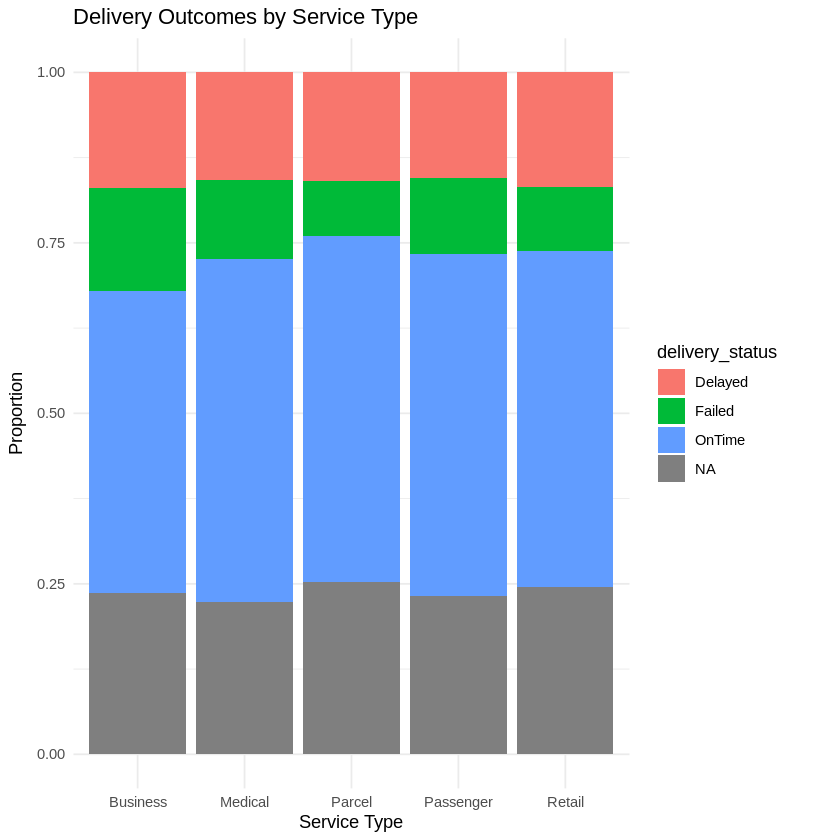

In [38]:
p1 <- ggplot(full_ops, aes(x = service_type, fill = delivery_status)) +
  geom_bar(position = "fill") +
  labs(
    title = "Delivery Outcomes by Service Type",
    x = "Service Type",
    y = "Proportion"
  ) +
  theme_minimal()

p1

`geom_smooth()` using formula = 'y ~ x'
Warning message:
“Removed 300 rows containing non-finite outside the scale range
(`stat_smooth()`).”
Warning message:
“Removed 300 rows containing missing values or values outside the scale range
(`geom_point()`).”


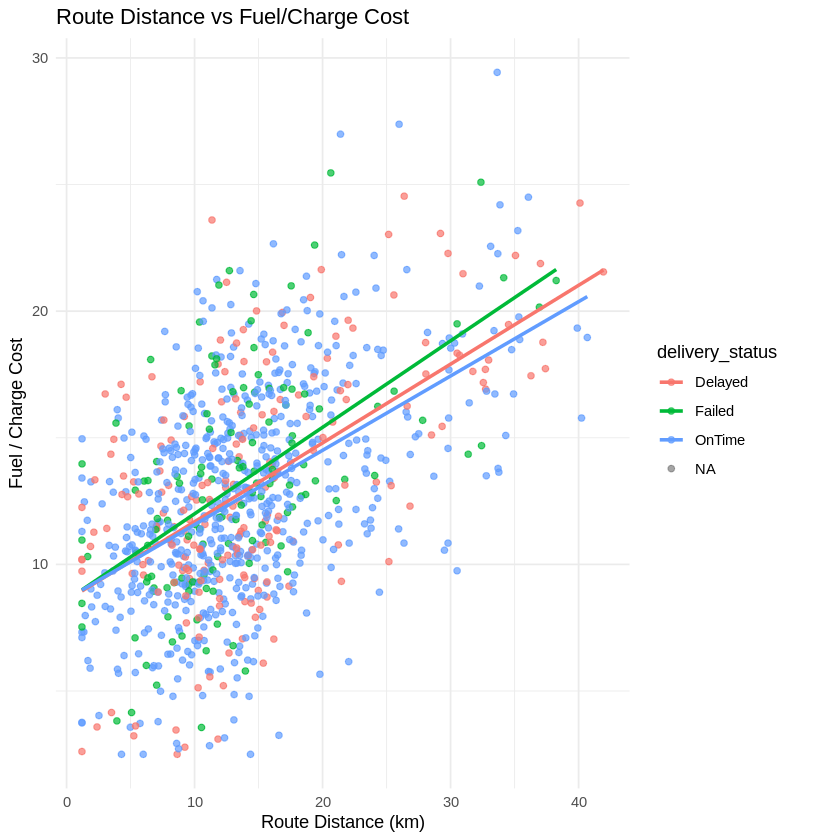

In [39]:
p2 <- ggplot(full_ops, aes(x = route_distance_km, y = fuel_or_charge_cost, color = delivery_status)) +
  geom_point(alpha = 0.7) +
  geom_smooth(method = "lm", se = FALSE) +
  labs(
    title = "Route Distance vs Fuel/Charge Cost",
    x = "Route Distance (km)",
    y = "Fuel / Charge Cost"
  ) +
  theme_minimal()

p2

Warning message:
“Removed 300 rows containing non-finite outside the scale range
(`stat_boxplot()`).”


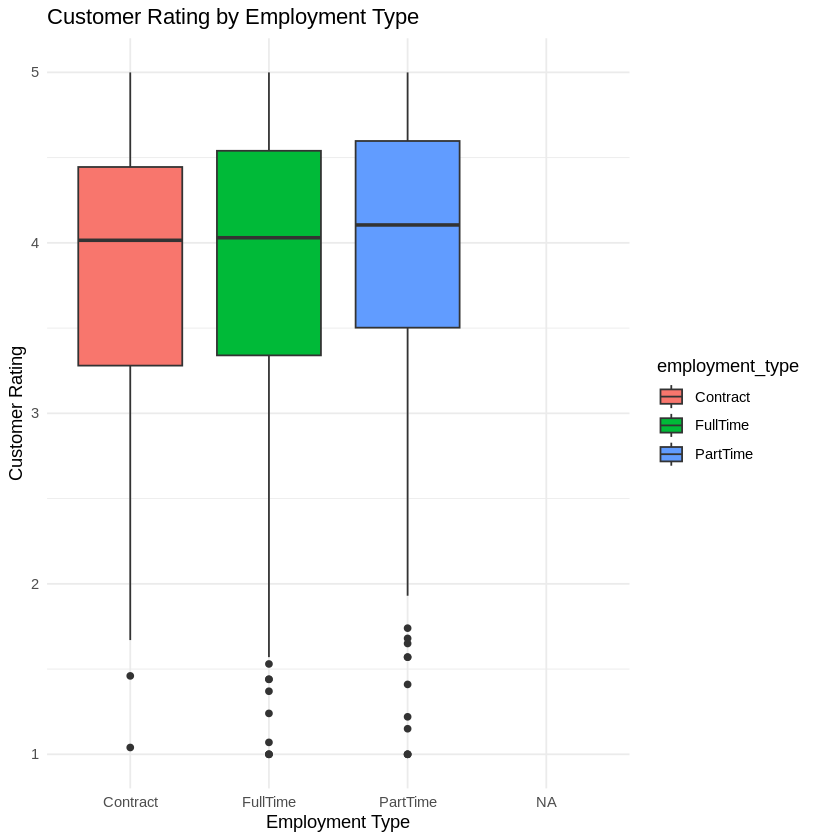

In [40]:
p3 <- ggplot(full_ops, aes(x = employment_type, y = customer_rating_post_delivery, fill = employment_type)) +
  geom_boxplot() +
  labs(
    title = "Customer Rating by Employment Type",
    x = "Employment Type",
    y = "Customer Rating"
  ) +
  theme_minimal()

p3

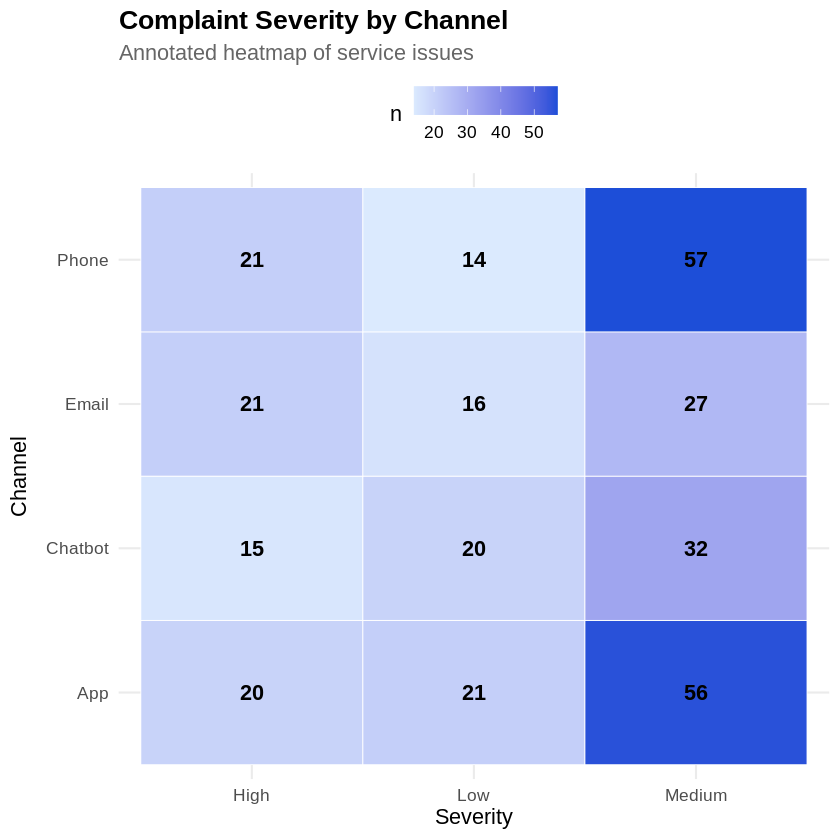

In [42]:
heat_df <- complaints %>%
  count(channel, severity)

ggplot(heat_df, aes(x = severity, y = channel, fill = n)) +
  geom_tile(color = "white") +
  geom_text(aes(label = n), fontface = "bold") +
  scale_fill_gradient(low = "#dbeafe", high = "#1d4ed8") +
  labs(
    title = "Complaint Severity by Channel",
    subtitle = "Annotated heatmap of service issues",
    x = "Severity", y = "Channel"
  ) +
  theme_hi()

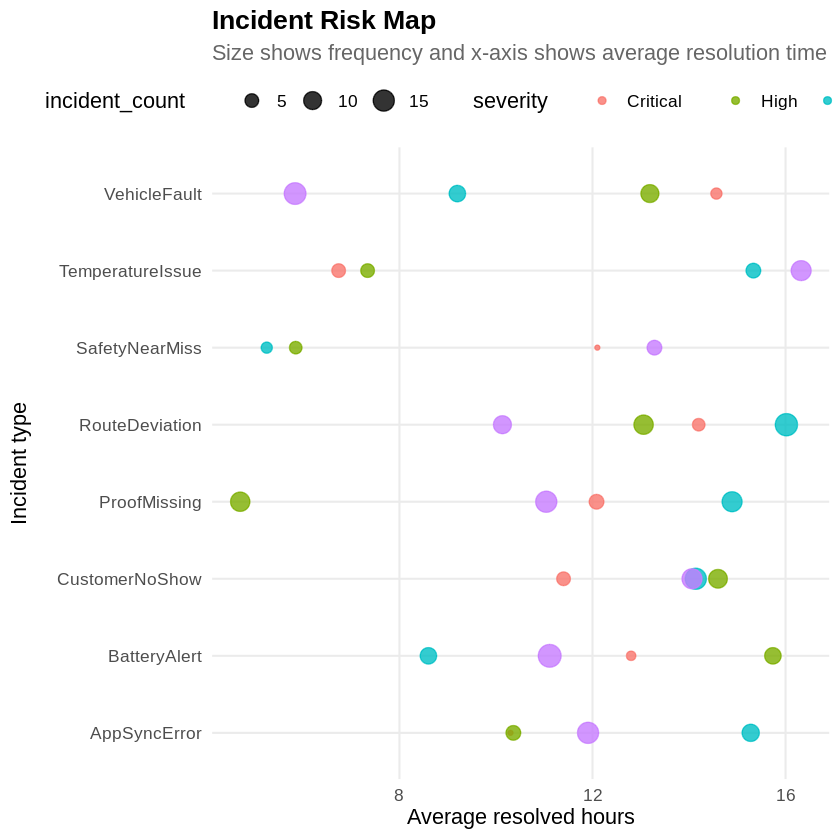

In [43]:
bubble_df <- incidents %>%
  count(incident_type, severity, name = "incident_count") %>%
  left_join(
    incidents %>%
      group_by(incident_type, severity) %>%
      summarise(avg_resolvedhours = mean(resolved_hours, na.rm = TRUE), .groups = "drop"),
    by = c("incident_type", "severity")
  )

ggplot(bubble_df, aes(x = avg_resolvedhours, y = incident_type, size = incident_count, color = severity)) +
  geom_point(alpha = 0.8) +
  labs(
    title = "Incident Risk Map",
    subtitle = "Size shows frequency and x-axis shows average resolution time",
    x = "Average resolved hours", y = "Incident type"
  ) +
  theme_hi()

In [41]:
write.csv(q1, "q1_service_type_failure.csv", row.names = FALSE)
write.csv(q2, "q2_zone_performance.csv", row.names = FALSE)
write.csv(q3, "q3_driver_ranking.csv", row.names = FALSE)
write.csv(q4, "q4_special_handling.csv", row.names = FALSE)
write.csv(q5, "q5_booking_channel.csv", row.names = FALSE)

cat("All output tables saved as CSV\n")

All output tables saved as CSV


In [44]:
dbDisconnect(con)
cat("SQLite connection closed\n")

SQLite connection closed
